# Embedding Inspector
Loads one processed image at a time, pairs each **view PNG** with its **DINOv3 patch embedding**, and shows:
- The raw MIP image
- A 14 × 14 heatmap of mean patch activation strength
- A PCA RGB visualisation of the patch embeddings (DINOv2-style)
- Per-view and cross-view metrics

## 0  Imports

In [1]:
import pickle
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from PIL import Image
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path("__file__").resolve().parent.parent
# If running from the src/ directory the above resolves to src/; fix it:
if (PROJECT_ROOT / "src").is_dir():
    pass  # already at project root
else:
    PROJECT_ROOT = PROJECT_ROOT.parent

PROC_ROOT = PROJECT_ROOT / "data" / "processed" / "bugNIST_900"
EMB_ROOT  = PROJECT_ROOT / "data" / "embeddings" / "bugNIST_900"

# PROC_ROOT = PROJECT_ROOT / "data" / "processed" 
# EMB_ROOT  = PROJECT_ROOT / "data" / "embeddings" 

print(f"Project root : {PROJECT_ROOT}")
print(f"Processed    : {PROC_ROOT}")
print(f"Embeddings   : {EMB_ROOT}")

Project root : /home/lyngsberg/bachelor_project
Processed    : /home/lyngsberg/bachelor_project/data/processed/bugNIST_900
Embeddings   : /home/lyngsberg/bachelor_project/data/embeddings/bugNIST_900


## 1  Discover available specimens & images

In [2]:
def list_available():
    """Return a dict {specimen: [image_name, ...]} for images that have both
    a processed folder AND a saved embedding."""
    available = {}
    for emb_file in sorted(EMB_ROOT.rglob("*.pkl")):
        specimen   = emb_file.parent.name          # e.g. 'GH'
        image_name = emb_file.stem                 # e.g. 'gras_9_042'
        proc_dir   = PROC_ROOT / specimen / image_name
        if proc_dir.is_dir():
            available.setdefault(specimen, []).append(image_name)
    return available

available = list_available()
for spec, images in available.items():
    print(f"{spec}: {images}")

GH: ['gras_9_043']


## 2  Select an image to inspect
Edit the two variables below.

In [16]:
SPECIMEN   = "GH"          # e.g. 'GH', 'SL', 'WO'
IMAGE_NAME = "gras_9_043"  # folder name inside data/processed/{SPECIMEN}/

proc_dir = PROC_ROOT / SPECIMEN / IMAGE_NAME
emb_path = EMB_ROOT  / SPECIMEN / f"{IMAGE_NAME}.pkl"

assert proc_dir.is_dir(), f"Processed folder not found: {proc_dir}"
assert emb_path.is_file(), f"Embedding file not found: {emb_path}"

# Load embedding dict  {view_name: np.ndarray(n_patches, hidden)}
with open(emb_path, "rb") as f:
    embeddings = pickle.load(f)

view_names = sorted(embeddings.keys())
n_views    = len(view_names)
sample_emb = embeddings[view_names[0]]
n_patches, hidden_size = sample_emb.shape
patch_grid = int(n_patches ** 0.5)   # should be 14 for 224-px images with patch_size=16
VIEWS_TO_SHOW = view_names
print(f"Specimen     : {SPECIMEN}")
print(f"Image        : {IMAGE_NAME}")
print(f"Views loaded : {n_views}")
print(f"Patch grid   : {patch_grid} × {patch_grid} = {n_patches} patches")
print(f"Hidden size  : {hidden_size}")

Specimen     : GH
Image        : gras_9_043
Views loaded : 10
Patch grid   : 90 × 90 = 8100 patches
Hidden size  : 384


In [15]:
embeddings

{'view_000': array([[-0.7918616 , -0.20332313,  0.02148944, ...,  0.24591021,
         -0.80337054,  0.3235038 ],
        [-0.7630182 , -0.20613024,  0.02840859, ...,  0.22959897,
         -0.78724396,  0.32998657],
        [-0.72046775, -0.21245629,  0.04826437, ...,  0.20989484,
         -0.76705056,  0.33260107],
        ...,
        [-0.32036844,  0.04639085, -0.26062438, ...,  0.92511594,
         -0.21596533, -0.13889328],
        [-0.34135658,  0.07108832, -0.2616586 , ...,  0.9329112 ,
         -0.23680961, -0.1648033 ],
        [-0.35682243,  0.09319904, -0.26343834, ...,  0.9410711 ,
         -0.24789765, -0.19294724]], shape=(8100, 384), dtype=float32),
 'view_001': array([[-0.76678467, -0.07258698,  0.08315905, ...,  0.22384344,
         -0.6700019 ,  0.3390567 ],
        [-0.73312724, -0.07319205,  0.08672878, ...,  0.20400015,
         -0.65378284,  0.3440303 ],
        [-0.683473  , -0.07782725,  0.10117304, ...,  0.1805925 ,
         -0.63176984,  0.34313715],
        .

## 3  Helper functions

In [8]:
def load_view_image(view_name: str) -> np.ndarray:
    """Load a view PNG as a greyscale numpy array (H, W)."""
    path = proc_dir / f"{view_name}.png"
    return np.array(Image.open(path).convert("L"))


def activation_heatmap(emb: np.ndarray, grid: int) -> np.ndarray:
    """Mean L2 norm per patch → (grid, grid) heatmap."""
    norms = np.linalg.norm(emb, axis=1)           # (n_patches,)
    return norms.reshape(grid, grid)


def pca_rgb(emb: np.ndarray, grid: int) -> np.ndarray:
    """
    Project patch embeddings to 3 PCA components and map to RGB.
    Returns uint8 image of shape (grid, grid, 3).
    """
    pca   = PCA(n_components=3)
    proj  = pca.fit_transform(emb)               # (n_patches, 3)
    # Normalise each channel to [0, 255]
    proj  = proj - proj.min(axis=0)
    proj  = proj / (proj.max(axis=0) + 1e-8)
    proj  = (proj * 255).astype(np.uint8)
    return proj.reshape(grid, grid, 3)

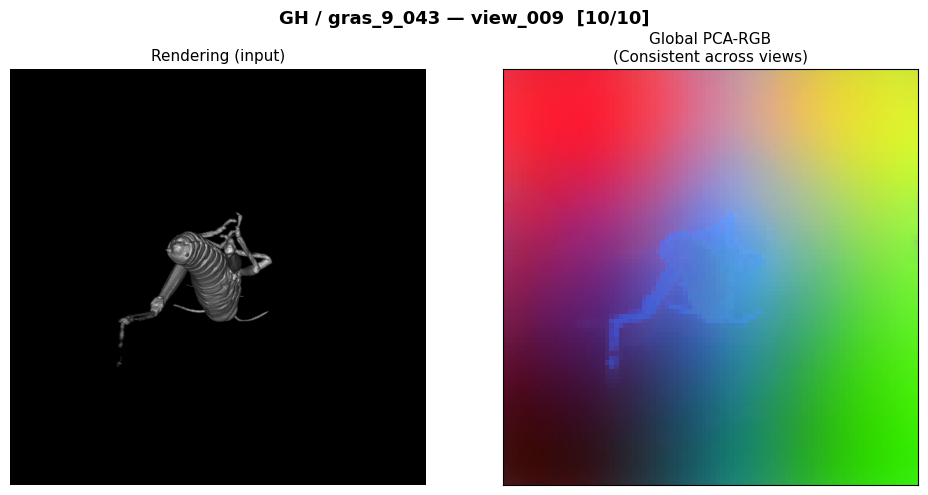

Done — all views shown.


In [18]:
import numpy as np
from sklearn.decomposition import PCA
from IPython.display import clear_output, display
import matplotlib.pyplot as plt
import time



# ── 1. Global PCA Setup ──────────────────────────────────────────────────────
# Flatten all embeddings into one matrix for a consistent coordinate system
all_embs_list = [embeddings[view_name] for view_name in VIEWS_TO_SHOW]
all_embs_stacked = np.vstack(all_embs_list)

n_components = 3
pca_global = PCA(n_components=n_components)
projected_all = pca_global.fit_transform(all_embs_stacked)

# Calculate global min/max for consistent RGB scaling across all images
p_min = projected_all.min(axis=0)
p_max = projected_all.max(axis=0)

def get_global_pca_rgb(emb, pca_model, p_min, p_max, grid_shape):
    """Projects local embeddings and scales to RGB based on global bounds."""
    proj = pca_model.transform(emb)
    
    # Linear scaling to [0, 1] range
    proj_norm = (proj - p_min) / (p_max - p_min + 1e-8)
    
    # Handle patch_grid as either an int or a tuple (H, W)
    if isinstance(grid_shape, (int, np.integer)):
        h = w = int(grid_shape)
    else:
        h, w = grid_shape
        
    return proj_norm.reshape(h, w, 3)

# ── 2. Visualization Loop ───────────────────────────────────────────────────
for view_name in VIEWS_TO_SHOW:
    emb = embeddings[view_name]
    img = load_view_image(view_name)
    
    # Transform embedding to PCA-RGB using global parameters
    pca_img = get_global_pca_rgb(emb, pca_global, p_min, p_max, patch_grid)

    clear_output(wait=True)

    # Changed to 1x2 layout
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(
        f"{SPECIMEN} / {IMAGE_NAME} — {view_name}  "
        f"[{VIEWS_TO_SHOW.index(view_name)+1}/{len(VIEWS_TO_SHOW)}]",
        fontsize=13, fontweight="bold"
    )

    # Panel 1: Raw Input
    axes[0].imshow(img, cmap="gray", origin="lower")
    axes[0].set_title("Rendering (input)", fontsize=11)
    axes[0].axis("off")

    # Panel 2: Global PCA-RGB
    axes[1].imshow(pca_img, origin="lower")
    axes[1].set_title("Global PCA-RGB\n(Consistent across views)", fontsize=11)
    axes[1].set_xticks([]); axes[1].set_yticks([])

    plt.tight_layout()
    display(fig)
    plt.close(fig)

    time.sleep(0.1)

print("Done — all views shown.")

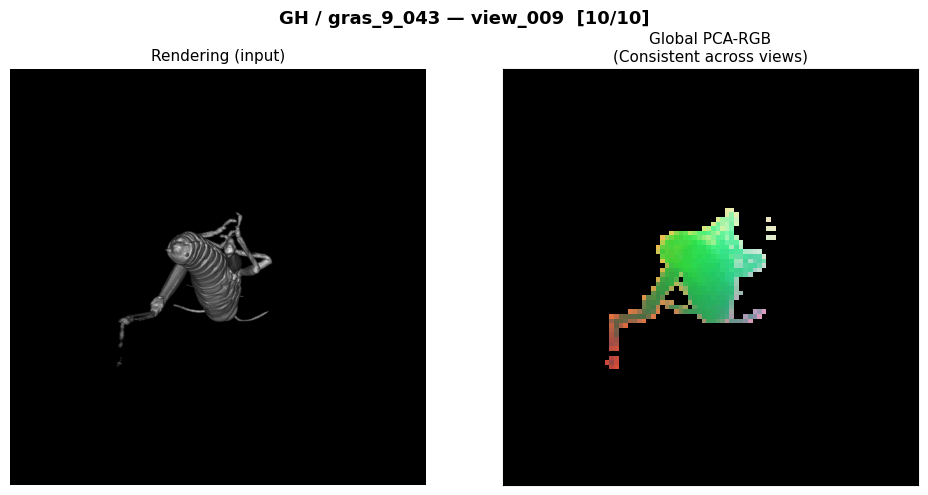

Done — all views shown.


In [21]:
import numpy as np
from sklearn.decomposition import PCA
from IPython.display import clear_output, display
import matplotlib.pyplot as plt
import time

# Helper function to detect black patches in the original image
def get_valid_patch_mask(img, grid_shape):
    """Returns a boolean mask of shape (H*W,) where True means the patch is NOT entirely black."""
    if isinstance(grid_shape, (int, np.integer)):
        h_grid = w_grid = int(grid_shape)
    else:
        h_grid, w_grid = grid_shape
        
    img_h, img_w = img.shape[:2]
    patch_h, patch_w = img_h // h_grid, img_w // w_grid
    
    mask = np.ones(h_grid * w_grid, dtype=bool)
    
    for i in range(h_grid):
        for j in range(w_grid):
            # Extract the patch from the image
            patch = img[i*patch_h:(i+1)*patch_h, j*patch_w:(j+1)*patch_w]
            
            # Check if entirely black (you can change this to np.max(patch) < threshold if there is noise)
            if np.all(patch == 0):
                mask[i * w_grid + j] = False
                
    return mask

# ── 1. Global PCA Setup ──────────────────────────────────────────────────────

valid_embs_list = []
view_masks = {}

# Pass 1: Identify black patches and collect ONLY valid embeddings for PCA
for view_name in VIEWS_TO_SHOW:
    emb = embeddings[view_name]
    img = load_view_image(view_name)
    
    # Generate the mask for this specific view
    mask = get_valid_patch_mask(img, patch_grid)
    view_masks[view_name] = mask
    
    # Extract only the embeddings corresponding to non-black patches
    valid_embs_list.append(emb[mask])

# Stack only the valid embeddings for a clean PCA fit
all_valid_embs_stacked = np.vstack(valid_embs_list)

n_components = 3
pca_global = PCA(n_components=n_components)
projected_valid = pca_global.fit_transform(all_valid_embs_stacked)

# Calculate global min/max ONLY on valid projections for accurate RGB scaling
p_min = projected_valid.min(axis=0)
p_max = projected_valid.max(axis=0)

def get_global_pca_rgb(emb, mask, pca_model, p_min, p_max, grid_shape):
    """Projects valid local embeddings and maps black patches to pure zeros."""
    if isinstance(grid_shape, (int, np.integer)):
        h = w = int(grid_shape)
    else:
        h, w = grid_shape
        
    # Initialize an entirely black canvas (Zeros will render as black)
    rgb_out = np.zeros((h * w, 3))
    
    # Project and scale ONLY the valid embeddings
    if np.any(mask):
        proj = pca_model.transform(emb[mask])
        proj_norm = (proj - p_min) / (p_max - p_min + 1e-8)
        
        # Inject the scaled colors back into the valid positions
        rgb_out[mask] = proj_norm
        
    return rgb_out.reshape(h, w, 3)

# ── 2. Visualization Loop ───────────────────────────────────────────────────
for view_name in VIEWS_TO_SHOW:
    emb = embeddings[view_name]
    img = load_view_image(view_name)
    mask = view_masks[view_name]
    
    # Transform embedding to PCA-RGB using global parameters and the mask
    pca_img = get_global_pca_rgb(emb, mask, pca_global, p_min, p_max, patch_grid)

    clear_output(wait=True)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(
        f"{SPECIMEN} / {IMAGE_NAME} — {view_name}  "
        f"[{VIEWS_TO_SHOW.index(view_name)+1}/{len(VIEWS_TO_SHOW)}]",
        fontsize=13, fontweight="bold"
    )

    # Panel 1: Raw Input
    axes[0].imshow(img, cmap="gray", origin="lower")
    axes[0].set_title("Rendering (input)", fontsize=11)
    axes[0].axis("off")

    # Panel 2: Global PCA-RGB
    axes[1].imshow(pca_img, origin="lower")
    axes[1].set_title("Global PCA-RGB\n(Consistent across views)", fontsize=11)
    axes[1].set_xticks([]); axes[1].set_yticks([])

    plt.tight_layout()
    display(fig)
    plt.close(fig)

    time.sleep(0.1)

print("Done — all views shown.")

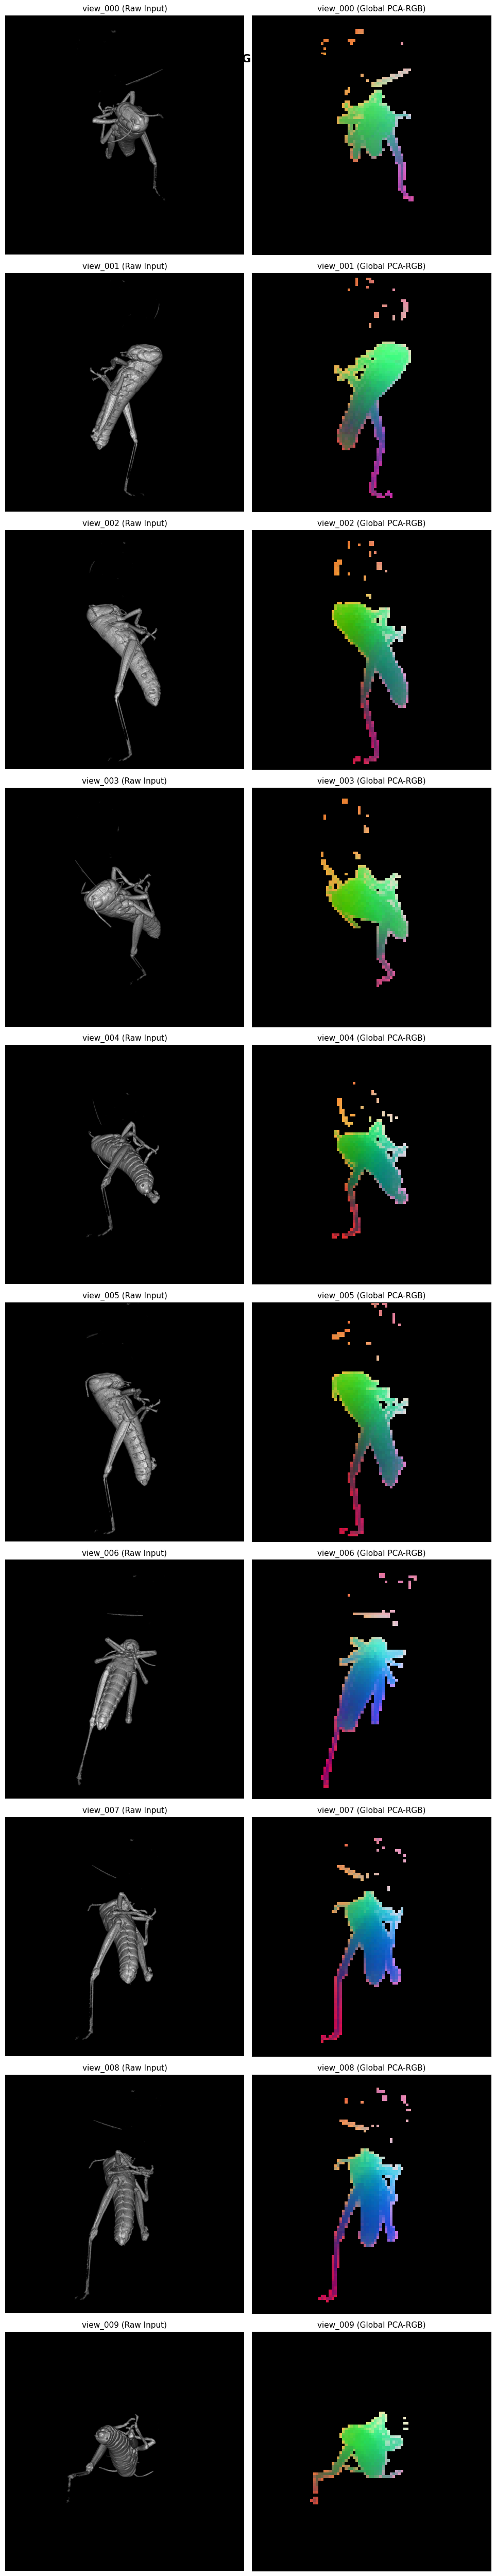

Done — all views rendered in the grid above.


In [22]:
# ── 2. Static Grid Visualization ────────────────────────────────────────────

num_views = len(VIEWS_TO_SHOW)

# Create a figure with N rows and 2 columns. 
# Height scales dynamically based on the number of views.
fig, axes = plt.subplots(nrows=num_views, ncols=2, figsize=(10, 5 * num_views))

# Ensure axes is always a 2D array even if there is only 1 view
if num_views == 1:
    axes = np.array([axes])

fig.suptitle(
    f"{SPECIMEN} / {IMAGE_NAME} — Global PCA Overview", 
    fontsize=16, 
    fontweight="bold"
)

for idx, view_name in enumerate(VIEWS_TO_SHOW):
    emb = embeddings[view_name]
    img = load_view_image(view_name)
    mask = view_masks[view_name]
    
    # Transform embedding to PCA-RGB using global parameters and the mask
    pca_img = get_global_pca_rgb(emb, mask, pca_global, p_min, p_max, patch_grid)

    # Extract the two subplots for the current row
    ax_raw, ax_pca = axes[idx]

    # Panel 1: Raw Input
    ax_raw.imshow(img, cmap="gray", origin="lower")
    ax_raw.set_title(f"{view_name} (Raw Input)", fontsize=11)
    ax_raw.axis("off")

    # Panel 2: Global PCA-RGB
    ax_pca.imshow(pca_img, origin="lower")
    ax_pca.set_title(f"{view_name} (Global PCA-RGB)", fontsize=11)
    ax_pca.set_xticks([])
    ax_pca.set_yticks([])

plt.tight_layout()

# Slightly adjust the top margin so the suptitle doesn't overlap the first row
plt.subplots_adjust(top=1.0 - (0.05 / max(1, num_views)))

plt.show()
print("Done — all views rendered in the grid above.")